# Inisiasi Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data & Informasinya

In [3]:
# Load data
df = pd.read_csv("D:\\Koding Liburan\\Full Dataset\\cleaning_prosperloadata.csv")

# Nampilin 5 baris pertama buat mastiin data udah masuk
display(df.head())

# Cek info dasar (jumlah baris, kolom, tipe data, dan data kosong)
print("\n--- Info Dataset ---")
df.info()

,Term,LoanStatus,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),...,StatedMonthlyIncome,LoanCurrentDaysDelinquent,LoanMonthsSinceOrigination,LoanOriginalAmount,MonthlyLoanPayment,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,36,Completed,0.16516,0.1580,0.1380,0.16214,0.0724,0.09140,4.0,C,...,3083.333333,0,78,9425,330.43,1.0,0,0,0.0,258
1,36,Current,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,...,6125.000000,0,0,10000,318.93,1.0,0,0,0.0,1
2,36,Completed,0.28269,0.2750,0.2400,0.16214,0.0724,0.09140,4.0,C,...,2083.333333,0,86,3001,123.32,1.0,0,0,0.0,41
3,36,Current,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,...,2875.000000,0,16,10000,321.45,1.0,0,0,0.0,158
4,36,Current,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,...,9583.333333,0,6,15000,563.97,1.0,0,0,0.0,20



--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6792 entries, 0 to 6791
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Term                                6792 non-null   int64  
 1   LoanStatus                          6792 non-null   object 
 2   BorrowerAPR                         6792 non-null   float64
 3   BorrowerRate                        6792 non-null   float64
 4   LenderYield                         6792 non-null   float64
 5   EstimatedEffectiveYield             6792 non-null   float64
 6   EstimatedLoss                       6792 non-null   float64
 7   EstimatedReturn                     6792 non-null   float64
 8   ProsperRating (numeric)             6792 non-null   float64
 9   ProsperRating (Alpha)               6792 non-null   object 
 10  ProsperScore                        6792 non-null   float64
 11  ListingCategory (nume

# Statistik Deskriptif

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Term,6792.0,40.992933,10.448178,12.00000,36.00000,36.000000,36.000000,60.00000
BorrowerAPR,6792.0,0.218892,0.080219,0.01657,0.15629,0.208690,0.283860,0.40243
BorrowerRate,6792.0,0.192763,0.074724,0.01000,0.13435,0.182400,0.250450,0.36000
LenderYield,6792.0,0.182723,0.074445,0.00150,0.12450,0.172400,0.240600,0.35250
EstimatedEffectiveYield,6792.0,0.167877,0.059468,-0.08360,0.13260,0.162140,0.195710,0.31990
EstimatedLoss,6792.0,0.078546,0.040616,0.00490,0.05490,0.072400,0.098000,0.36600
EstimatedReturn,6792.0,0.095247,0.026590,-0.08360,0.08022,0.091400,0.109410,0.25700
ProsperRating (numeric),6792.0,4.048145,1.443954,1.00000,3.00000,4.000000,5.000000,7.00000
ProsperScore,6792.0,5.939488,2.059708,1.00000,5.00000,6.000000,7.000000,11.00000
ListingCategory (numeric),6792.0,2.890901,4.141265,0.00000,1.00000,1.000000,3.000000,20.00000


# Cek Missing Value

In [5]:
# Cek Missing Value
print(df.isnull().sum())

# Cek Duplikasi
print("Jumlah data duplikat:", df.duplicated().sum())

Term                                  0
LoanStatus                            0
BorrowerAPR                           0
BorrowerRate                          0
LenderYield                           0
EstimatedEffectiveYield               0
EstimatedLoss                         0
EstimatedReturn                       0
ProsperRating (numeric)               0
ProsperRating (Alpha)                 0
ProsperScore                          0
ListingCategory (numeric)             0
BorrowerState                         0
Occupation                            0
EmploymentStatus                      0
EmploymentStatusDuration              0
IsBorrowerHomeowner                   0
CurrentlyInGroup                      0
CreditScoreRangeLower                 0
CreditScoreRangeUpper                 0
CurrentCreditLines                    0
OpenCreditLines                       0
TotalCreditLinespast7years            0
OpenRevolvingAccounts                 0
OpenRevolvingMonthlyPayment           0


# Cek Outlier 

C:\Users\USER\AppData\Local\Temp\ipykernel_30776\3697142977.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='StatedMonthlyIncome', palette='Set1')
C:\Users\USER\AppData\Local\Temp\ipykernel_30776\3697142977.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='DebtToIncomeRatio', palette='Set1')


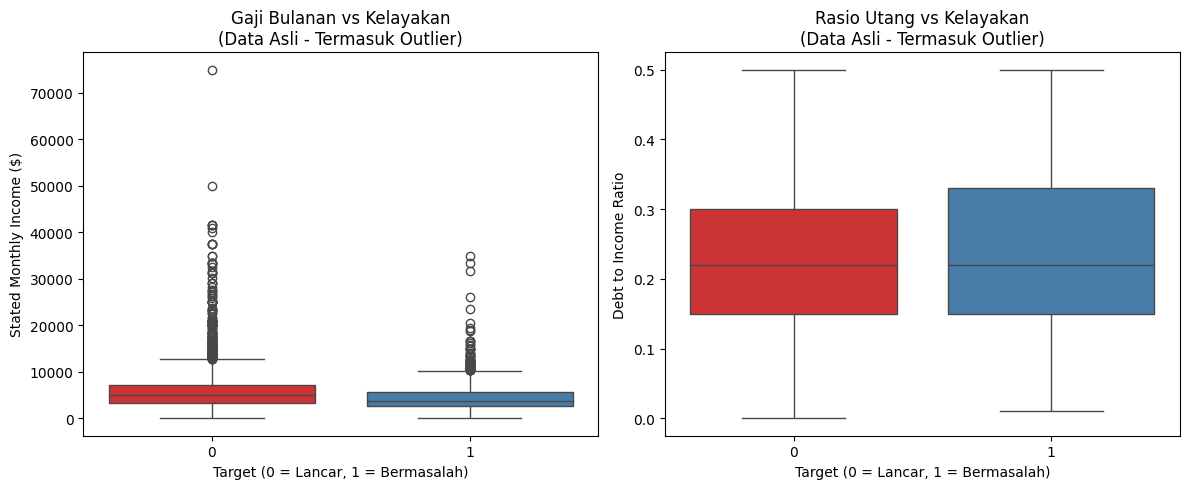

In [6]:
# 2. Bikin ulang kolom 'Target' (0 = Lancar, 1 = Bermasalah)
df['Target'] = df['LoanStatus'].apply(lambda x: 0 if x in ['Completed', 'Current'] else 1)

# 3. Bikin canvas gambar aslinya
plt.figure(figsize=(12, 5))

# Boxplot 1: Gaji Bulanan
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Target', y='StatedMonthlyIncome', palette='Set1')
plt.title('Gaji Bulanan vs Kelayakan\n(Data Asli - Termasuk Outlier)')
plt.xlabel('Target (0 = Lancar, 1 = Bermasalah)')
plt.ylabel('Stated Monthly Income ($)')

# Boxplot 2: Rasio Utang
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Target', y='DebtToIncomeRatio', palette='Set1')
plt.title('Rasio Utang vs Kelayakan\n(Data Asli - Termasuk Outlier)')
plt.xlabel('Target (0 = Lancar, 1 = Bermasalah)')
plt.ylabel('Debt to Income Ratio')

plt.tight_layout()
plt.show()

# Cek Konsistensi Kolom Kategorikal

In [7]:
# 1. Kita ambil dulu semua kolom yang tipe datanya 'object' (teks)
kolom_kategorikal = df.select_dtypes(include=['object']).columns

# 2. Kita cek ada berapa banyak variasi (kardinalitas) di masing-masing kolom
print("--- Jumlah Variasi (Kardinalitas) Data Teks ---")
for kolom in kolom_kategorikal:
    print(f"{kolom} memiliki {df[kolom].nunique()} nilai unik")

print("\n" + "="*50 + "\n")

# 3. Sekarang kita cek satu-satu konsistensi penulisannya
# Kita mulai dari kolom yang variasinya dikit (biar gampang dibaca)

print("--- Pengecekan Isi Kolom: EmploymentStatus ---")
print(df['EmploymentStatus'].value_counts(dropna=False)) # dropna=False biar ketahuan kalo ada NaN

print("\n--- Pengecekan Isi Kolom: IncomeRange ---")
print(df['IncomeRange'].value_counts(dropna=False))

print("\n--- Pengecekan Isi Kolom: ProsperRating (Alpha) ---")
print(df['ProsperRating (Alpha)'].value_counts(dropna=False))

--- Jumlah Variasi (Kardinalitas) Data Teks ---
LoanStatus memiliki 11 nilai unik
ProsperRating (Alpha) memiliki 7 nilai unik
BorrowerState memiliki 50 nilai unik
Occupation memiliki 66 nilai unik
EmploymentStatus memiliki 8 nilai unik
IncomeRange memiliki 8 nilai unik


--- Pengecekan Isi Kolom: EmploymentStatus ---
EmploymentStatus
Employed         4174
Full-time        1544
Self-employed     379
Not available     295
Other             238
Part-time          68
Not employed       48
Retired            46
Name: count, dtype: int64

--- Pengecekan Isi Kolom: IncomeRange ---
IncomeRange
$25,000-49,999    1956
$50,000-74,999    1847
$100,000+         1040
$75,000-99,999    1004
Not displayed      446
$1-24,999          418
Not employed        47
$0                  34
Name: count, dtype: int64

--- Pengecekan Isi Kolom: ProsperRating (Alpha) ---
ProsperRating (Alpha)
C     2785
B      975
A      858
D      846
E      606
HR     412
AA     310
Name: count, dtype: int64


# Distribusi Kelayakan

C:\Users\USER\AppData\Local\Temp\ipykernel_30776\1205281503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target', palette='Set2')


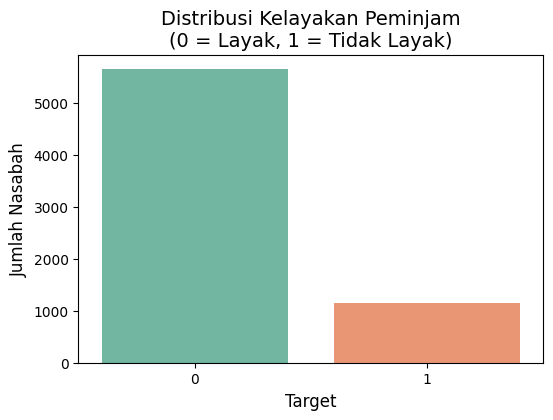

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Target', palette='Set2')
plt.title('Distribusi Kelayakan Peminjam\n(0 = Layak, 1 = Tidak Layak)', fontsize=14)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Jumlah Nasabah', fontsize=12)
plt.show()

# Analisis Univariat

C:\Users\USER\AppData\Local\Temp\ipykernel_30776\3661086205.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='EmploymentStatus', palette='viridis',


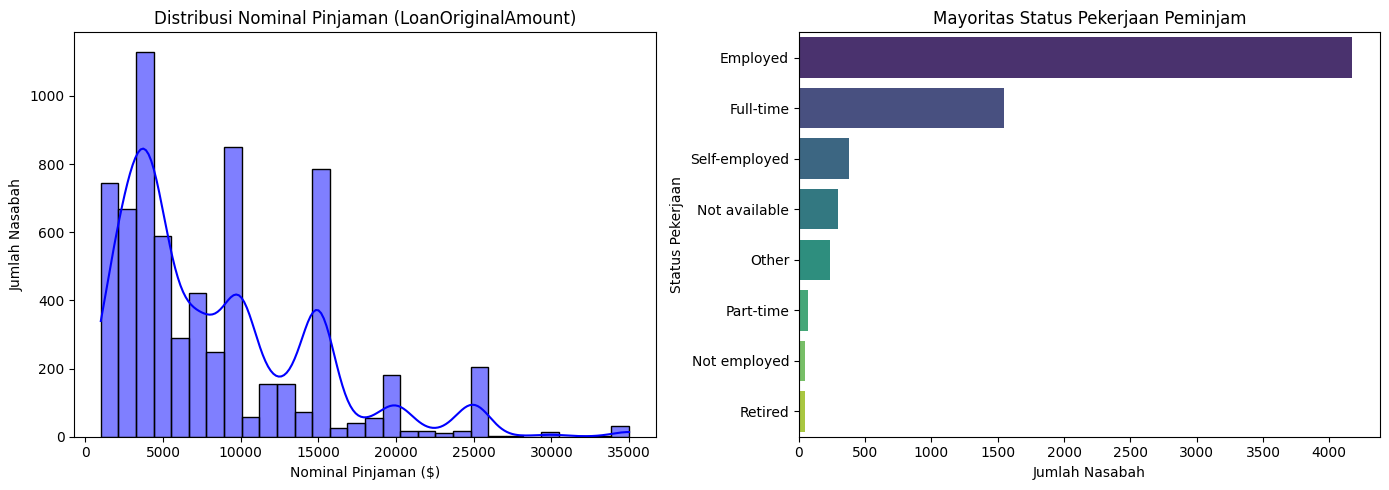

In [9]:
plt.figure(figsize=(14, 5))

# Grafik 1: Distribusi Nominal Pinjaman (Univariat Numerik)
plt.subplot(1, 2, 1)
sns.histplot(df['LoanOriginalAmount'], bins=30, kde=True, color='blue')
plt.title('Distribusi Nominal Pinjaman (LoanOriginalAmount)')
plt.xlabel('Nominal Pinjaman ($)')
plt.ylabel('Jumlah Nasabah')

# Grafik 2: Distribusi Status Pekerjaan (Univariat Kategorikal)
plt.subplot(1, 2, 2)
sns.countplot(data=df, y='EmploymentStatus', palette='viridis', 
              order=df['EmploymentStatus'].value_counts().index)
plt.title('Mayoritas Status Pekerjaan Peminjam')
plt.xlabel('Jumlah Nasabah')
plt.ylabel('Status Pekerjaan')

plt.tight_layout()
plt.show()

# Analisis Bivariat

C:\Users\USER\AppData\Local\Temp\ipykernel_30776\1786945675.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='ProsperScore', palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_30776\1786945675.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='IsBorrowerHomeowner', y='Target', palette='Set2')


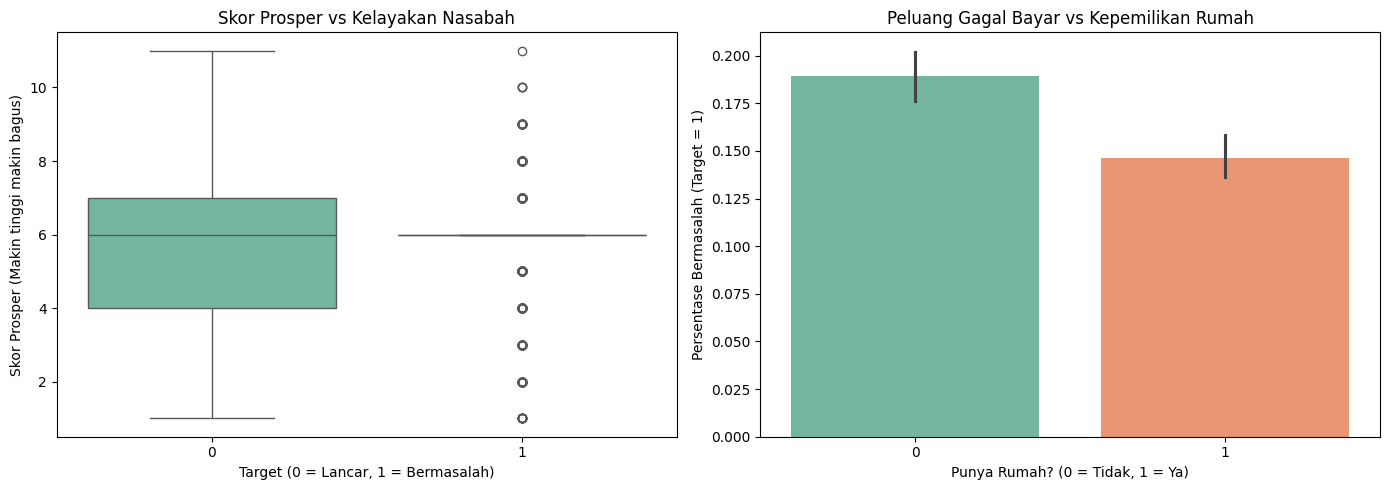

In [10]:
plt.figure(figsize=(14, 5))

# Grafik 1: Hubungan Skor Risiko dengan Kelayakan (Numerik vs Target)
# ProsperScore itu skor dari aplikasinya (1 paling berisiko, 11 paling aman)
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Target', y='ProsperScore', palette='Set2')
plt.title('Skor Prosper vs Kelayakan Nasabah')
plt.xlabel('Target (0 = Lancar, 1 = Bermasalah)')
plt.ylabel('Skor Prosper (Makin tinggi makin bagus)')

# Grafik 2: Hubungan Punya Rumah dengan Kelayakan (Kategorikal vs Target)
plt.subplot(1, 2, 2)
# Pake barplot buat liat persentase gagal bayar
sns.barplot(data=df, x='IsBorrowerHomeowner', y='Target', palette='Set2')
plt.title('Peluang Gagal Bayar vs Kepemilikan Rumah')
plt.xlabel('Punya Rumah? (0 = Tidak, 1 = Ya)')
plt.ylabel('Persentase Bermasalah (Target = 1)')

plt.tight_layout()
plt.show()

# Analisis Multivariat

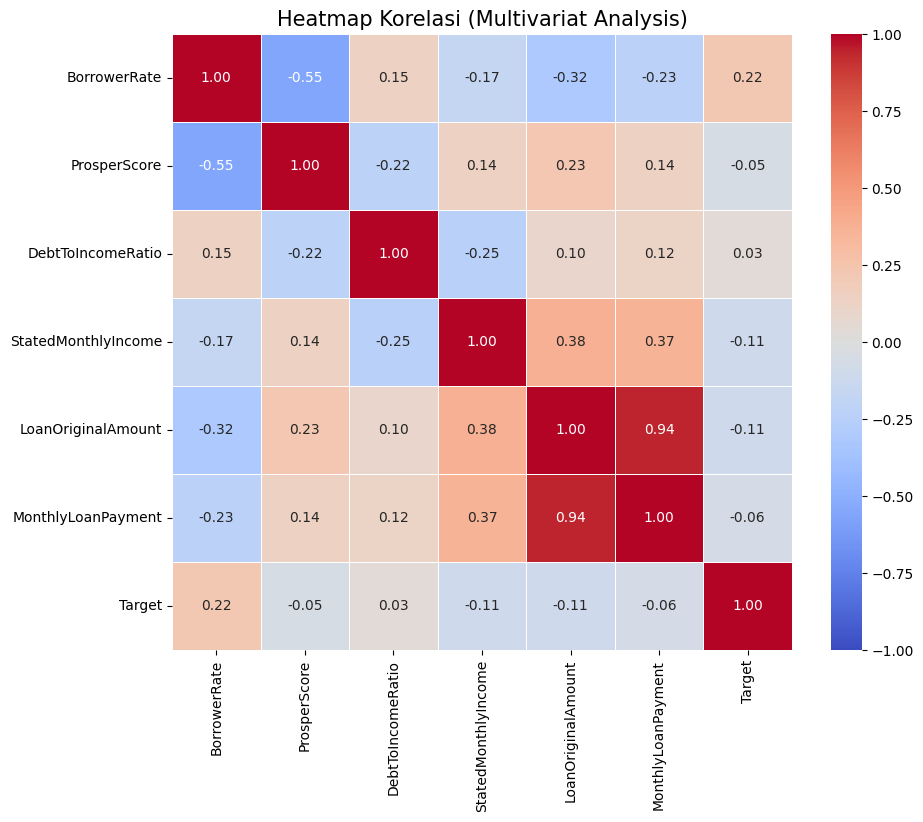

In [11]:
# Pilih beberapa kolom numerik penting aja
kolom_penting = [
    'BorrowerRate', 'ProsperScore', 'DebtToIncomeRatio', 
    'StatedMonthlyIncome', 'LoanOriginalAmount', 'MonthlyLoanPayment', 'Target'
]

plt.figure(figsize=(10, 8))
# Hitung korelasi
korelasi = df[kolom_penting].corr()

# Gambar Heatmap-nya
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi (Multivariat Analysis)', fontsize=15)
plt.show()

In [12]:
# 2. Bikin Target (0 = Lancar, 1 = Bermasalah)
df['Target'] = df['LoanStatus'].apply(lambda x: 0 if x in ['Completed', 'Current'] else 1)

# 3. Buang Data Leakage (Bocor Masa Depan) & Kolom Status Asli
kolom_bocor = [
    'LoanCurrentDaysDelinquent', 
    'LoanMonthsSinceOrigination', 
    'AmountDelinquent',
    'CurrentDelinquencies',
    'LoanStatus'
]
df_bersih = df.drop(columns=kolom_bocor, errors='ignore')

# 4. Save ke CSV baru khusus buat Machine Learning
df_bersih.to_csv('data_siap_ml.csv', index=False)
print("Mantap! Data EDA udah bersih dan berhasil disimpen sebagai 'data_siap_ml.csv'")

Mantap! Data EDA udah bersih dan berhasil disimpen sebagai 'data_siap_ml.csv'
